Дискретное преобразование Фурье и быстрое преобразование Фурье

n = 1024

1. Единичный импульс
$$ 
F = \begin{cases}
F(0) = 1 \\
F(n) = 0
\end{cases}
$$

2. Константа
$$
F(n) = A, A - const
$$

3. Сумма синусов
$$
F = \sin(2\pi f_1) + sin(2\pi f_2)
$$

4. Синус с белым шумом
$$
F = \sin(2\pi f) + \text{rand}(n)
$$

5. Гауссово распределение
$$
F = \frac1{\sqrt{2\pi}} \int_{-\infty}^{\infty} e ^{-\frac{x^2}2} dx
$$


In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
N = 1024

t_min = -1
t_max = 1

t = np.linspace(t_min, t_max, N)

In [6]:
def FImpulse(t):
    if abs(t) <= 0.001:
        return 1
    else:
        return 0

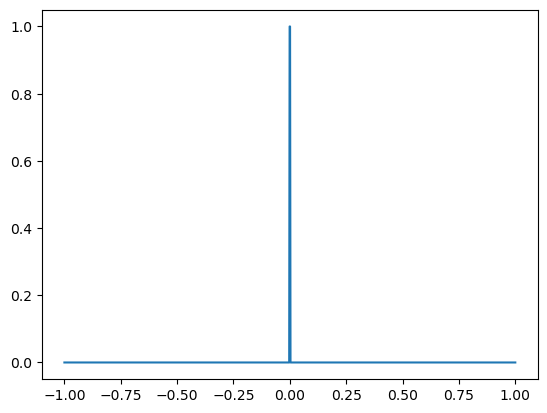

In [7]:
signal = [FImpulse(time) for time in t]

plt.plot(t, signal)

In [8]:
def DiscreteFurieTransform(data):
    coef = 2 * np.pi / len(data)
    fft_data = []
    for k in range(len(data)):
        re_el = 0
        im_el = 0
        for n in range(len(data)):
            re_el += data[n] * np.cos(coef * k * n)
            im_el += -data[n] * np.sin(coef * k * n)
        fft_data.append((re_el, im_el))
        
    return fft_data

In [ ]:
def FFT(data):
    N = len(data)
    
    if N <= 32:  # this cutoff should be optimized
        return DiscreteFurieTransform(data)
    else:
        X_even = FFT(data[::2]) # 0, 2, 4, ...
        X_odd = FFT(data[1::2]) # 1, 3, 5, ...
        for k in range(N):
            
            for n in range(N//2 - 1):
                alpha = 2 * np.pi * k * n / N
                X_odd[0] = np.cos(alpha  / 2) - np.sin(alpha / 2) * X_odd[1]
                X_odd[1] = 

/usr/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


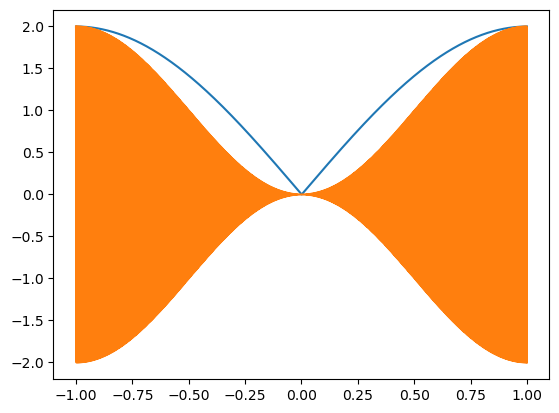

In [ ]:
dft = DiscreteFurieTransform(signal)
fft = FFT(signal)
dft_ = np.fft.fft(signal)

ampl = [np.sqrt(el[0]**2 + el[1]**2) for el in dft]
ampl_F = [np.sqrt(el[0]**2 + el[1]**2) for el in dft]
plt.plot(t, ampl)
ampl = [el for el in dft_]
plt.plot(t, ampl)

In [ ]:
def FastFurieTransform(data):

#include <vector>
#include <complex>

using namespace std;

typedef complex<double> cd;
typedef vector<cd> vcd;

vcd fft(const vcd &as) { 
  int n = as.size();
  if (n == 1) return vcd(1, as[0]);

  vcd w(n); // Calculate roots
  for (int i = 0; i < n; i++) {
    double alpha = 2 * M_PI * i / n;
    w[i] = cd(cos(alpha), sin(alpha));
  }

  vcd A(n / 2), B(n / 2);
  for (int i = 0; i < n / 2; i++) {
    A[i] = as[i * 2];
    B[i] = as[i * 2 + 1];
  }
  vcd Av = fft(A);
  vcd Bv = fft(B);
  vcd res(n);
  for (int i = 0; i < n; i++)
    res[i] =   Av[i % (n / 2)] +
        w[i] * Bv[i % (n / 2)];
  return res;
}